### Final Model Evaluation and Feature Ablation Analysis of  of the gait-based person identification model, including exhaustive trial-grouped validation, performance distributions, feature ablation experiments, and robustness analysis.


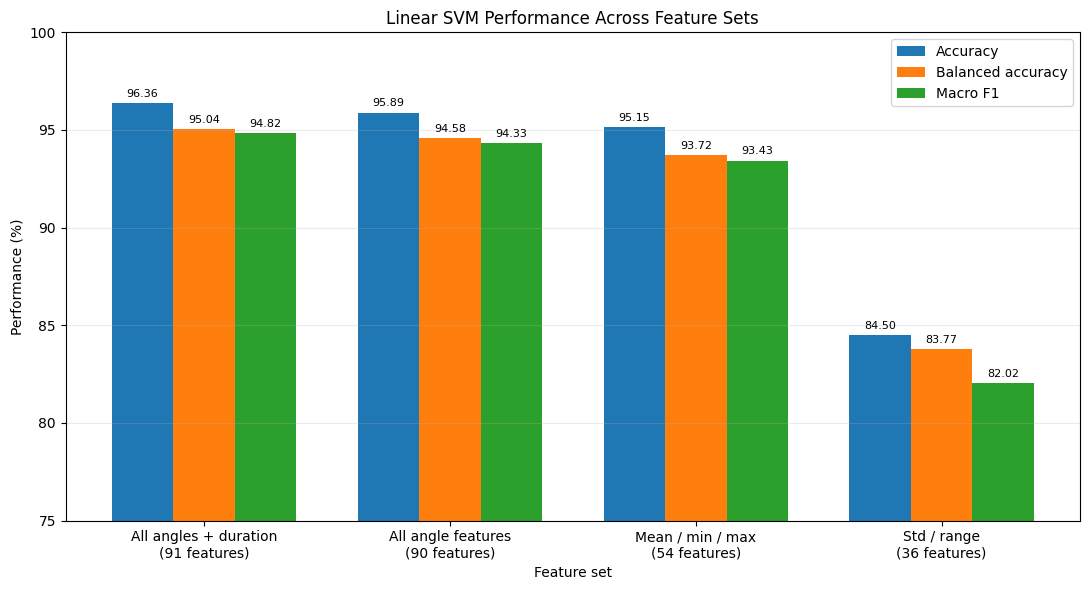

,Feature set,Accuracy,Balanced accuracy,Macro F1
0,All angles + duration\n(91 features),96.36,95.04,94.82
1,All angle features\n(90 features),95.89,94.58,94.33
2,Mean / min / max\n(54 features),95.15,93.72,93.43
3,Std / range\n(36 features),84.50,83.77,82.02


In [22]:
# FINAL FIGURE 1 — Feature-set ablation comparison

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_comparison = pd.DataFrame({
    "Feature set": [
        "All angles + duration\n(91 features)",
        "All angle features\n(90 features)",
        "Mean / min / max\n(54 features)",
        "Std / range\n(36 features)"
    ],
    "Accuracy": [96.36, 95.89, 95.15, 84.50],
    "Balanced accuracy": [95.04, 94.58, 93.72, 83.77],
    "Macro F1": [94.82, 94.33, 93.43, 82.02]
})

x = np.arange(len(feature_comparison))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

b1 = ax.bar(
    x - width,
    feature_comparison["Accuracy"],
    width,
    label="Accuracy"
)

b2 = ax.bar(
    x,
    feature_comparison["Balanced accuracy"],
    width,
    label="Balanced accuracy"
)

b3 = ax.bar(
    x + width,
    feature_comparison["Macro F1"],
    width,
    label="Macro F1"
)

ax.set_ylabel("Performance (%)")
ax.set_xlabel("Feature set")
ax.set_title("Linear SVM Performance Across Feature Sets")

ax.set_xticks(x)
ax.set_xticklabels(feature_comparison["Feature set"])

# Keep enough range to show the real differences
ax.set_ylim(75, 100)

ax.legend()

ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(b3, fmt="%.2f", padding=3, fontsize=8)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

display(feature_comparison)

In [23]:
# CELL 2 — Load exhaustive evaluation results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

exhaustive_results_df = pd.read_csv(
    "exhaustive_svm_results.csv"
)

print("Loaded exhaustive results.")
print("Number of trial-holdout combinations:", len(exhaustive_results_df))

display(exhaustive_results_df.head())

print("\nPerformance summary:")
display(
    exhaustive_results_df[
        ["accuracy", "balanced_accuracy", "macro_f1"]
    ].describe().round(4)
)

Loaded exhaustive results.
Number of trial-holdout combinations: 1440


,split_id,accuracy,balanced_accuracy,macro_f1,test_cycles
0,1,0.977528,0.960000,0.963376,89
1,2,0.971429,0.960000,0.968022,70
2,3,0.968085,0.955455,0.951553,94
3,4,0.967391,0.955238,0.952308,92
4,5,0.963964,0.950476,0.956025,111



Performance summary:


,accuracy,balanced_accuracy,macro_f1
count,1440.0000,1440.0000,1440.0000
mean,0.9636,0.9504,0.9482
std,0.0218,0.0316,0.0322
min,0.8500,0.7939,0.7884
25%,0.9514,0.9330,0.9313
50%,0.9663,0.9511,0.9536
75%,0.9781,0.9730,0.9699
max,1.0000,1.0000,1.0000


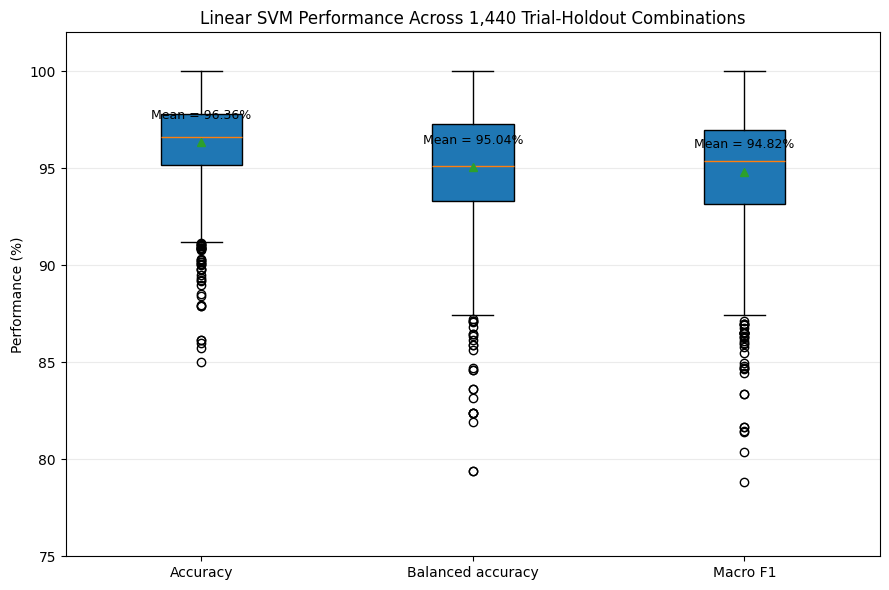

In [24]:
# CELL 3 — Performance distribution across all exhaustive splits

metrics_to_plot = [
    ("accuracy", "Accuracy"),
    ("balanced_accuracy", "Balanced accuracy"),
    ("macro_f1", "Macro F1")
]

data = [
    exhaustive_results_df[col].values * 100
    for col, _ in metrics_to_plot
]

labels = [label for _, label in metrics_to_plot]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True
)

ax.set_ylabel("Performance (%)")
ax.set_title(
    "Linear SVM Performance Across 1,440 "
    "Trial-Holdout Combinations"
)

ax.set_ylim(75, 102)
ax.grid(axis="y", alpha=0.25)

for i, (col, _) in enumerate(metrics_to_plot, start=1):

    mean_value = exhaustive_results_df[col].mean() * 100

    ax.text(
        i,
        mean_value + 1.2,
        f"Mean = {mean_value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [25]:
# CELL 5 — Performance loss relative to full 91-feature model

baseline_acc = feature_comparison.loc[0, "Accuracy"]
baseline_bal = feature_comparison.loc[0, "Balanced accuracy"]
baseline_f1 = feature_comparison.loc[0, "Macro F1"]

ablation_loss = feature_comparison.copy()

ablation_loss["Accuracy change"] = (
    ablation_loss["Accuracy"] - baseline_acc
)

ablation_loss["Balanced accuracy change"] = (
    ablation_loss["Balanced accuracy"] - baseline_bal
)

ablation_loss["Macro F1 change"] = (
    ablation_loss["Macro F1"] - baseline_f1
)

display(
    ablation_loss.round(2)
)

,Feature set,Accuracy,Balanced accuracy,Macro F1,Accuracy change,Balanced accuracy change,Macro F1 change
0,All angles + duration\n(91 features),96.36,95.04,94.82,0.00,0.00,0.00
1,All angle features\n(90 features),95.89,94.58,94.33,-0.47,-0.46,-0.49
2,Mean / min / max\n(54 features),95.15,93.72,93.43,-1.21,-1.32,-1.39
3,Std / range\n(36 features),84.50,83.77,82.02,-11.86,-11.27,-12.80


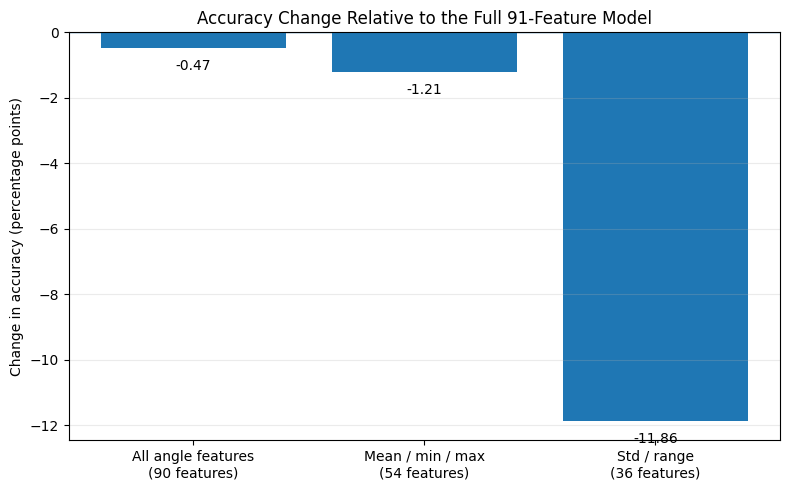

In [26]:
# CELL 6 — Accuracy loss relative to full model

loss_plot = ablation_loss.iloc[1:].copy()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    loss_plot["Feature set"],
    loss_plot["Accuracy change"]
)

ax.axhline(0, linewidth=1)

ax.set_ylabel("Change in accuracy (percentage points)")
ax.set_title(
    "Accuracy Change Relative to the Full 91-Feature Model"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, loss_plot["Accuracy change"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value - 0.35,
        f"{value:.2f}",
        ha="center",
        va="top"
    )

plt.tight_layout()
plt.show()

In [27]:
# CELL 7 — Final exhaustive evaluation statistics

final_exhaustive_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1"
    ],

    "Mean (%)": [
        exhaustive_results_df["accuracy"].mean() * 100,
        exhaustive_results_df["balanced_accuracy"].mean() * 100,
        exhaustive_results_df["macro_f1"].mean() * 100
    ],

    "Std (%)": [
        exhaustive_results_df["accuracy"].std() * 100,
        exhaustive_results_df["balanced_accuracy"].std() * 100,
        exhaustive_results_df["macro_f1"].std() * 100
    ],

    "Minimum (%)": [
        exhaustive_results_df["accuracy"].min() * 100,
        exhaustive_results_df["balanced_accuracy"].min() * 100,
        exhaustive_results_df["macro_f1"].min() * 100
    ],

    "Maximum (%)": [
        exhaustive_results_df["accuracy"].max() * 100,
        exhaustive_results_df["balanced_accuracy"].max() * 100,
        exhaustive_results_df["macro_f1"].max() * 100
    ]
})

display(
    final_exhaustive_summary.round(2)
)

,Metric,Mean (%),Std (%),Minimum (%),Maximum (%)
0,Accuracy,96.36,2.18,85.00,100.0
1,Balanced accuracy,95.04,3.16,79.39,100.0
2,Macro F1,94.82,3.22,78.84,100.0


In [28]:
# CELL 8 — Save final result tables

feature_comparison.to_csv(
    "final_feature_comparison.csv",
    index=False
)

ablation_loss.to_csv(
    "final_feature_ablation_loss.csv",
    index=False
)

final_exhaustive_summary.to_csv(
    "final_exhaustive_summary.csv",
    index=False
)

print("Final result tables saved successfully.")

Final result tables saved successfully.
